In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yeanzc/telco-customer-churn-ibm-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\aqill\.cache\kagglehub\datasets\yeanzc\telco-customer-churn-ibm-dataset\versions\1


In [12]:
import pandas as pd

file_name = "Telco_customer_churn.xlsx"

# Pake read_excel ya cok, bukan read_csv!
df = pd.read_excel(file_name)

print("=== 5 BARIS PERTAMA ===")
display(df.head())

print("\n=== KESEHATAN DATA ===")
df.info()

=== 5 BARIS PERTAMA ===


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices



=== KESEHATAN DATA ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Se

In [13]:
# 1. Benerin tipe data Total Charges (paksa jadi angka, kalo error jadi NaN)
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Karena tadi dipaksa, pasti ada nilai kosong (NaN). Kita isi pake angka 0 aja.
df['Total Charges'] = df['Total Charges'].fillna(0)

# 2. Buang kolom-kolom yang nggak guna buat Prediksi ML
kolom_sampah = [
    'CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
    'Lat Long', 'Latitude', 'Longitude', 'Churn Reason', 'Churn Label', 'Churn Score'
]
df_bersih = df.drop(columns=kolom_sampah)

# 3. Ganti spasi di nama kolom jadi underscore (biar kodingan gampang)
df_bersih.columns = df_bersih.columns.str.replace(' ', '_')

# Cek hasilnya!
print("=== KESEHATAN DATA SETELAH DIBERSIHIN ===")
df_bersih.info()

display(df_bersih.head(3))

=== KESEHATAN DATA SETELAH DIBERSIHIN ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   str    
 1   Senior_Citizen     7043 non-null   str    
 2   Partner            7043 non-null   str    
 3   Dependents         7043 non-null   str    
 4   Tenure_Months      7043 non-null   int64  
 5   Phone_Service      7043 non-null   str    
 6   Multiple_Lines     7043 non-null   str    
 7   Internet_Service   7043 non-null   str    
 8   Online_Security    7043 non-null   str    
 9   Online_Backup      7043 non-null   str    
 10  Device_Protection  7043 non-null   str    
 11  Tech_Support       7043 non-null   str    
 12  Streaming_TV       7043 non-null   str    
 13  Streaming_Movies   7043 non-null   str    
 14  Contract           7043 non-null   str    
 15  Paperless_Billing  7043 non-null   str   

,Gender,Senior_Citizen,Partner,Dependents,Tenure_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,Online_Backup,...,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Value,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372


C:\Users\aqill\AppData\Local\Temp\ipykernel_16200\711108073.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_bersih, x='Churn_Value', ax=axes[0], palette=['#2ECC71', '#E74C3C'])
C:\Users\aqill\AppData\Local\Temp\ipykernel_16200\711108073.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bersih, x='Churn_Value', y='Tenure_Months', ax=axes[2], palette=['#2ECC71', '#E74C3C'])


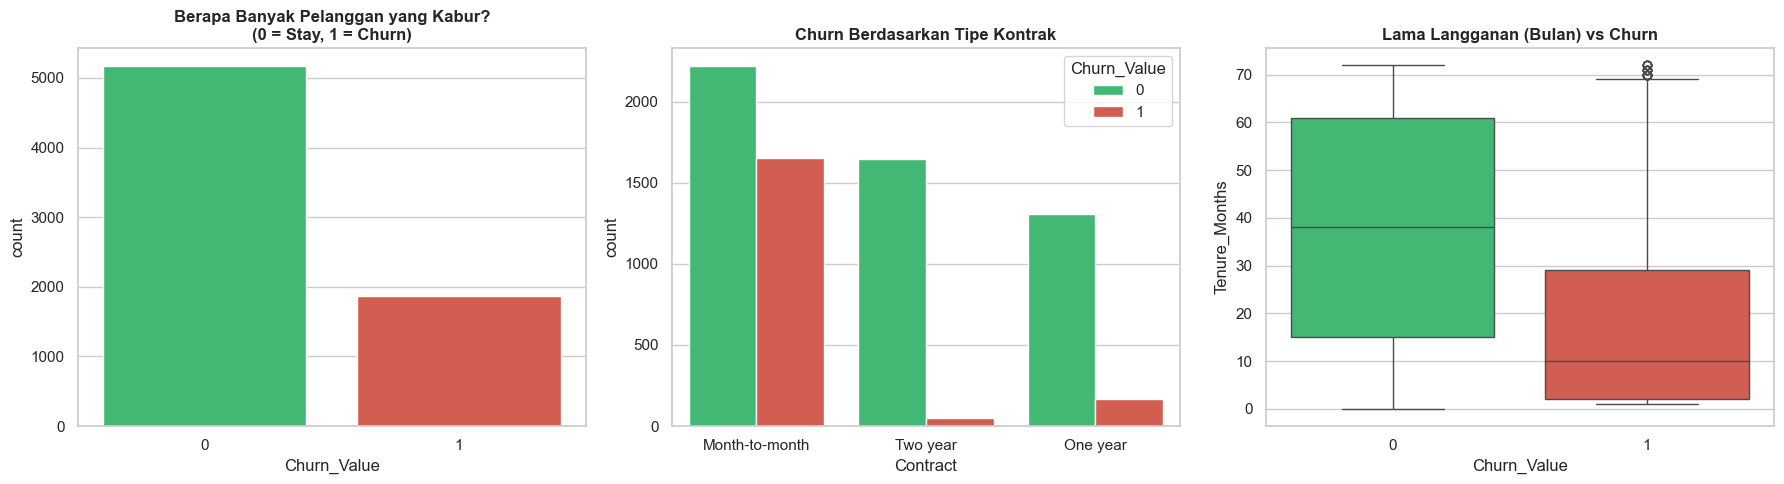

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Atur tema biar grafiknya estetik ala portofolio lu
sns.set_theme(style="whitegrid")

# Bikin kanvas panjang buat naruh 3 grafik jejeran
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- GRAFIK 1: Berapa banyak sih yang kabur? ---
sns.countplot(data=df_bersih, x='Churn_Value', ax=axes[0], palette=['#2ECC71', '#E74C3C'])
axes[0].set_title('Berapa Banyak Pelanggan yang Kabur?\n(0 = Stay, 1 = Churn)', fontweight='bold')

# --- GRAFIK 2: Hubungan Tipe Kontrak sama Churn ---
sns.countplot(data=df_bersih, x='Contract', hue='Churn_Value', ax=axes[1], palette=['#2ECC71', '#E74C3C'])
axes[1].set_title('Churn Berdasarkan Tipe Kontrak', fontweight='bold')

# --- GRAFIK 3: Hubungan Lama Berlangganan (Tenure) sama Churn ---
sns.boxplot(data=df_bersih, x='Churn_Value', y='Tenure_Months', ax=axes[2], palette=['#2ECC71', '#E74C3C'])
axes[2].set_title('Lama Langganan (Bulan) vs Churn', fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Copy data biar aman
df_ml = df_bersih.copy()

# 1. Label Encoding buat kolom yang isinya cuma "Yes" / "No"
kolom_yes_no = ['Partner', 'Dependents', 'Phone_Service', 'Paperless_Billing']
le = LabelEncoder()
for col in kolom_yes_no:
    df_ml[col] = le.fit_transform(df_ml[col])

# Kolom Gender juga sekalian (Female = 0, Male = 1)
df_ml['Gender'] = le.fit_transform(df_ml['Gender'])

# 2. One-Hot Encoding (pd.get_dummies) buat kolom yang kategorinya > 2
# Contoh: Contract (Month-to-month, One year, Two year) bakal dibelah jadi kolom-kolom baru
kolom_kategori_banyak = ['Multiple_Lines', 'Internet_Service', 'Online_Security', 
                         'Online_Backup', 'Device_Protection', 'Tech_Support', 
                         'Streaming_TV', 'Streaming_Movies', 'Contract', 'Payment_Method']

df_ml = pd.get_dummies(df_ml, columns=kolom_kategori_banyak, drop_first=True)

# 3. Pisahin mana fitur pembantu (X) dan mana target tembakan (y)
X = df_ml.drop(columns=['Churn_Value']) # X isinya semua kolom KECUALI jawaban churn-nya
y = df_ml['Churn_Value'] # y isinya KUNCI JAWABAN (Churn 1 atau 0)

# 4. Belah data jadi 2: Buat latihan (Training) dan buat ujian (Testing) 
# Kita pake porsi 80% latihan, 20% ujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data berhasil dibelah!")
print(f"Jumlah Data Latihan: {X_train.shape[0]} baris")
print(f"Jumlah Data Ujian: {X_test.shape[0]} baris")

Data berhasil dibelah!
Jumlah Data Latihan: 5634 baris
Jumlah Data Ujian: 1409 baris


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Copy data biar aman
df_ml = df_bersih.copy()

# 1. Label Encoding buat kolom yang isinya cuma "Yes" / "No"
kolom_yes_no = ['Partner', 'Dependents', 'Phone_Service', 'Paperless_Billing']
le = LabelEncoder()
for col in kolom_yes_no:
    df_ml[col] = le.fit_transform(df_ml[col])

# Kolom Gender juga sekalian (Female = 0, Male = 1)
df_ml['Gender'] = le.fit_transform(df_ml['Gender'])

# --- TAMBAHAN BARU: Beresin Senior Citizen ---
# Paksa kolom Senior_Citizen jadi angka (karena isinya '1' dan '0' tapi nyamar jadi teks)
df_ml['Senior_Citizen'] = pd.to_numeric(df_ml['Senior_Citizen'], errors='coerce').fillna(0).astype(int)

# 2. One-Hot Encoding (pd.get_dummies) buat kolom yang kategorinya > 2
kolom_kategori_banyak = ['Multiple_Lines', 'Internet_Service', 'Online_Security', 
                         'Online_Backup', 'Device_Protection', 'Tech_Support', 
                         'Streaming_TV', 'Streaming_Movies', 'Contract', 'Payment_Method']

df_ml = pd.get_dummies(df_ml, columns=kolom_kategori_banyak, drop_first=True)

# --- TAMBAHAN BARU: Paksa semua boolean (True/False) dari get_dummies jadi angka (1/0) ---
for col in df_ml.columns:
    if df_ml[col].dtype == 'bool':
        df_ml[col] = df_ml[col].astype(int)

# 3. Pisahin mana fitur pembantu (X) dan mana target tembakan (y)
X = df_ml.drop(columns=['Churn_Value'])
y = df_ml['Churn_Value']

# 4. Belah data jadi 2: Buat latihan (Training) dan buat ujian (Testing) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data berhasil dibelah & dibersihin total!")

Data berhasil dibelah & dibersihin total!


⏳ XGBoost sedang belajar dari 5634 baris data...
✅ Proses belajar selesai!

🎯 AKURASI MODEL: 79.35%

=== RAPOR LENGKAP (CLASSIFICATION REPORT) ===
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1009
           1       0.66      0.57      0.61       400

    accuracy                           0.79      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.79      0.79      0.79      1409



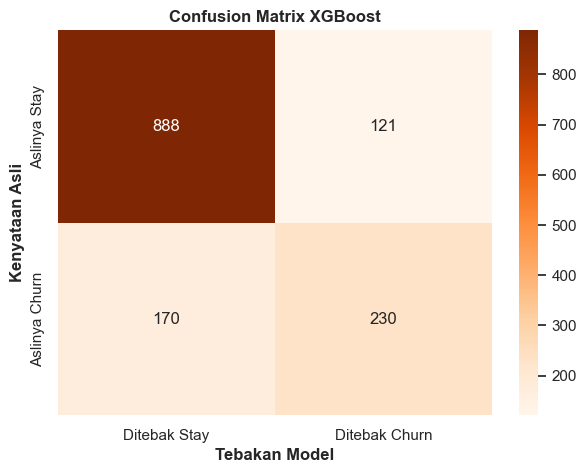

In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Bangunkan Sang Monster XGBoost
# Kita pake settingan default dulu, dia udah pinter dari sananya
model_xgb = XGBClassifier(random_state=42, eval_metric='logloss')

# 2. Latih Modelnya (Proses Belajar)
print("⏳ XGBoost sedang belajar dari 5634 baris data...")
model_xgb.fit(X_train, y_train)
print("✅ Proses belajar selesai!\n")

# 3. Uji Modelnya pake soal ujian (1409 baris data yang belum pernah dia liat)
y_pred = model_xgb.predict(X_test)

# 4. Liat Nilai Rapornya!
akurasi = accuracy_score(y_test, y_pred)
print(f"🎯 AKURASI MODEL: {akurasi * 100:.2f}%\n")

print("=== RAPOR LENGKAP (CLASSIFICATION REPORT) ===")
print(classification_report(y_test, y_pred))

# 5. Visualisasi Confusion Matrix (Biar gampang liat bener/salah tebakannya)
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Ditebak Stay', 'Ditebak Churn'], 
            yticklabels=['Aslinya Stay', 'Aslinya Churn'])
plt.title('Confusion Matrix XGBoost', fontweight='bold')
plt.ylabel('Kenyataan Asli', fontweight='bold')
plt.xlabel('Tebakan Model', fontweight='bold')
plt.show()